#### KNN Regresiion 으로 50cm 생선의 무게 예측

In [2]:
import numpy as np

In [3]:
fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_length,
        fish_weight,
        random_state=42
    )

In [8]:
# 1열로 구성된 배열로 재구성
test_input = test_input.reshape(-1,1)
train_input = train_input.reshape(-1, 1)

#### KNN Regression Model

In [9]:
from sklearn.neighbors import KNeighborsRegressor

In [10]:
# 이웃의 갯수를 3으로 선택
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### 길이가 50cm인 생선의 무게를 예측

In [11]:
knr.predict([[50]])

array([1033.33333333])

#### 기존 데이터로 무게 확인

In [19]:
for i, v in list(enumerate(train_target)):
    if v == train_target.max():
        print(train_input[i], v)


[43.] 1100.0
[42.] 1100.0


> 기존 데이터에서는 길이가 42, 43 cm 인 경우에 무게가 1.1Kg이 나왔는데,    
50cm인 경우에 1Kg이 좀 넘게 나왔다..???

#### 산점도로 이웃을 구해서 확인해 보자

In [20]:
import matplotlib.pyplot as plt

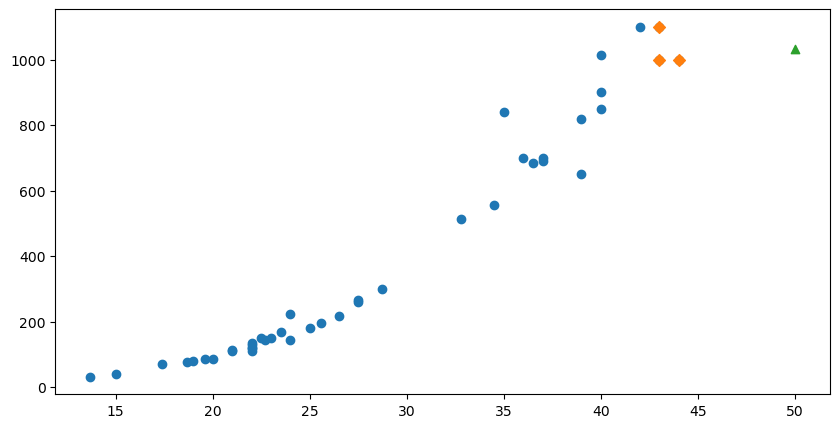

In [23]:
# 50cm인 생선의 이웃을 찾자
distance, indexes = knr.kneighbors([[50]])

# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(train_input, train_target)

# 이웃을 그리자
plt.scatter(
    train_input[indexes],
    train_target[indexes],
    marker='D'
)

# 50cm 생선 데이터
plt.scatter(
    50,
    1033,
    marker='^'
)

plt.show()

In [24]:
# 이웃들의 평균값 계산
np.mean(train_target[indexes])

np.float64(1033.3333333333333)

#### 길이가 100cm 인 생선의 무게 예측

In [26]:
# 길이가 100cm인 생선의 무게
knr.predict([[100]])

array([1033.33333333])

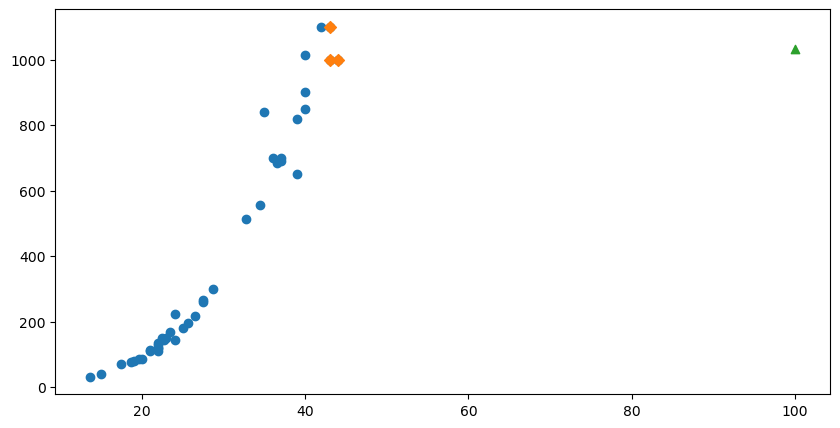

In [ ]:
# 시각화로 확인
distance, indexes = knr.kneighbors([[100]])

# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(train_input, train_target)

# 이웃을 그리자
plt.scatter(
    train_input[indexes],
    train_target[indexes],
    marker='D'
)

# 100cm 생선 데이터
plt.scatter(
    100,
    1033,
    marker='^'
)

plt.show()

> KNN Regression은 주변 이웃의 값들의 평균을 구하는 것이므로 학습한 데이터의 범위를 벗어나게 되면 사용할 수 없다.

----
#### 선형 회귀(Linear Regression)     
: 직선이나 곡선의 함수식(방정식: Y=aX+b)을 이용하여 구하는 방식으로 로지스틱 회귀분석이나 인공신경망의 기초가 되었다.

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
# model
lr = LinearRegression()

lr.fit(train_input, train_target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
lr.predict([[50]])

array([1241.83860323])

In [31]:
# Y=aX+b 에서 기울기와 절편 출력(Deep Learning에서는 weight, Bias로 불림)
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535477


In [32]:
39.01714496 * 50 -709.0186449535477

1241.8386030464526

#### 산점도 그려보기

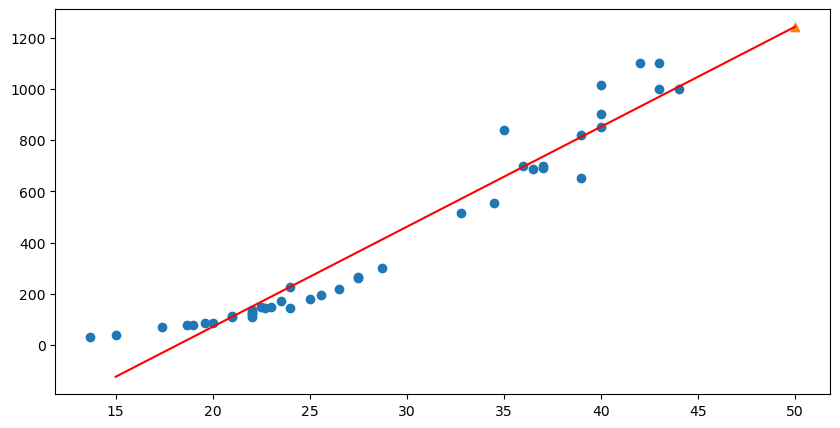

In [35]:
# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(train_input, train_target)

# 길이가 15 ~ 50 까지 1차방정식 그래프
plt.plot(
    [15, 50],
    [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_],
    c='red'
)

# 50cm 생선
plt.scatter(50, 1241.8, marker='^')
plt.show()

> 산점도의 회귀선을 보니 길이가 작아지면 무게가 음수가 발생할 수 있다.    
절편이 음수이다.

----
#### 특성공학(Feature Engineering)
##### 다항회귀
Y=aX+b -> Y=aX^2 + bX + c
##### 다중회귀
Y=aX1+aX2...+ b 

In [36]:
# Feature를 제곱한 Column을 생성하여 기존의 Column에 붙인다.
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

In [37]:
# 크기확인
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [38]:
train_poly

array([[ 384.16,   19.6 ],
       [ 484.  ,   22.  ],
       [ 349.69,   18.7 ],
       [ 302.76,   17.4 ],
       [1296.  ,   36.  ],
       [ 625.  ,   25.  ],
       [1600.  ,   40.  ],
       [1521.  ,   39.  ],
       [1849.  ,   43.  ],
       [ 484.  ,   22.  ],
       [ 400.  ,   20.  ],
       [ 484.  ,   22.  ],
       [ 576.  ,   24.  ],
       [ 756.25,   27.5 ],
       [1849.  ,   43.  ],
       [1600.  ,   40.  ],
       [ 576.  ,   24.  ],
       [ 441.  ,   21.  ],
       [ 756.25,   27.5 ],
       [1600.  ,   40.  ],
       [1075.84,   32.8 ],
       [ 702.25,   26.5 ],
       [1332.25,   36.5 ],
       [ 187.69,   13.7 ],
       [ 515.29,   22.7 ],
       [ 225.  ,   15.  ],
       [1369.  ,   37.  ],
       [1225.  ,   35.  ],
       [ 823.69,   28.7 ],
       [ 552.25,   23.5 ],
       [1521.  ,   39.  ],
       [ 441.  ,   21.  ],
       [ 529.  ,   23.  ],
       [ 484.  ,   22.  ],
       [1936.  ,   44.  ],
       [ 506.25,   22.5 ],
       [ 361.  ,   19.  ],
 

In [39]:
# Model 생성
lr = LinearRegression()

In [40]:
# 훈련
lr.fit(train_poly, train_target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
# 50cm 생선의 무게 예측
lr.predict([[50**2, 50]])

array([1573.98423528])

In [42]:
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


In [43]:
1.01433211* 50**2 + -21.55792498 * 50 + 116.0502107827827

1573.9842367827825

#### 산점도 그리기

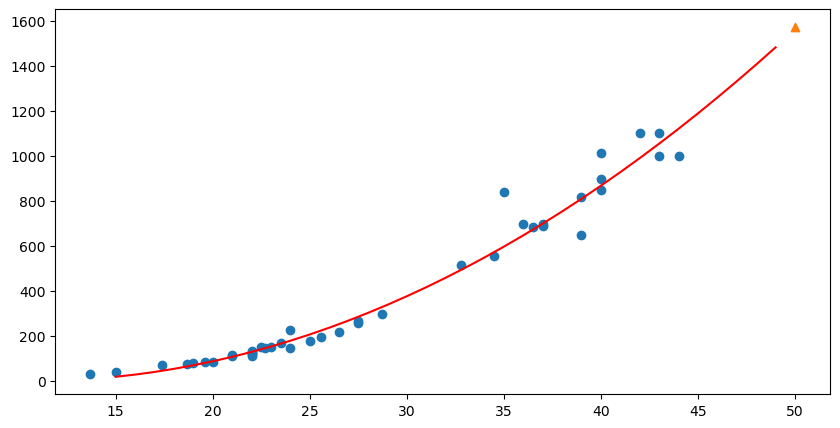

In [44]:
# 훈련세트의 산점도
plt.figure(figsize=(10,5))
plt.scatter(train_input, train_target)

# 길이가 15 ~ 50 까지 1차방정식 그래프
point = np.arange(15, 50)
plt.plot(
    point,
    1.01*point**2 -21.6*point + 116.05,
    c='red'
)

# 50cm 생선
plt.scatter(50, 1574, marker='^')
plt.show()